# SatIQ Plots: Models

This notebook is used to generate all the "model" plots (results and analysis on trained models) in the "SatIQ" paper.

## Setup

In [1]:
plot_dir = "../plots/models"
data_base = "../data/"
fig_width = 12.0 # Width of a figure that spans 100% of the page width
fig_height = 8.0 # Height of a figure that spans 100% of the page width
def fig_size(scale=1.0, height=1.0, square=False):
    if not square:
        return (fig_width * scale, fig_height * scale * height)
    else:
        return (fig_width * scale, fig_width * scale)

In [2]:
import os
import functools
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
import json
import pickle
import re

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from multiprocessing import Pool

import seaborn as sns
import colorsys
import matplotlib.colors as mcolors

import ast
tqdm.pandas()

In [3]:
def get_palette():
    colors = [
        (190, 15, 52),
        (72, 145, 220),
        (0, 119, 112),
    ]
    colors += [ (int(r*256), int(g*256), int(b*256)) for r, g, b in sns.color_palette('colorblind')[len(colors):] ]
    colors_hex = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in colors]

    return colors_hex

def get_palette_gradient(ref):
    if ref == "fingerprinting":
        hls_start = [ colorsys.rgb_to_hls(*color) for color in sns.color_palette("rocket", as_cmap=False, n_colors=256) ]
        hue_shift = colorsys.rgb_to_hls(*[ c / 255 for c in (190, 15, 52) ])[0] - hls_start[130][0]
        colors_shifted = [ colorsys.hls_to_rgb((hue + hue_shift) % 1, l, s) for (hue, l, s) in hls_start ]
        palette_gradient = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors_shifted)
    elif ref == "fingerprinting_2":
        colors_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in
            [
                (235, 196, 203),
                (190, 15, 52),
                (135, 36, 52)
            ]
        ]
        colors_gradient_str = ','.join(colors_gradient)
        palette_gradient = sns.color_palette(f"blend:{colors_gradient_str}", as_cmap=True)
    elif ref == "fingerprinting_3":
        colors_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in
            [
                (235, 196, 203),
                (190, 15, 52),
                (135, 36, 52)
            ]
        ]
        colors_gradient_str = ','.join(colors_gradient)
        palette_gradient = sns.color_palette(f"blend:#ffffff,{colors_gradient_str}", as_cmap=True)
    else:
        raise ValueError(f"Unknown reference: {ref}")

    return palette_gradient

sns.set_theme(palette=get_palette(), color_codes=True)
palette_gradient = get_palette_gradient("fingerprinting")

sns.set_style('ticks')
sns.set_context('notebook', font_scale=1.3)
plt.rcParams['figure.dpi'] = 72
#plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs

sns.color_palette(get_palette())

[(0.7450980392156863, 0.058823529411764705, 0.20392156862745098),
 (0.2823529411764706, 0.5686274509803921, 0.8627450980392157),
 (0.0, 0.4666666666666667, 0.4392156862745098),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
# Decorator to add optional output_pdf and show arguments to plot functions
def plot_d(func, save_dir):
    @functools.wraps(func)
    def wrapper(*args, output_pdf=None, dpi=None, show=True, **kwargs):
        res = func(*args, **kwargs)

        if output_pdf is not None:
            if dpi is None:
                plt.savefig(os.path.join(save_dir, output_pdf), bbox_inches='tight')
            else:
                plt.savefig(os.path.join(save_dir, output_pdf), bbox_inches='tight', dpi=dpi)
        if show:
            plt.show()
        plt.close()

        return res

    return wrapper

os.makedirs(plot_dir, exist_ok=True)
plot = functools.partial(plot_d, save_dir=plot_dir)

In [5]:
data_dir = os.path.join(data_base, "tfrecord")
model_dir = os.path.join(data_base, "models")
label_dir = os.path.join(data_base, "test", "labels")
embedding_dir = os.path.join(data_base, 'test', 'embeddings')
results_dir = os.path.join(data_base, "results")

data_pastai = os.path.join(data_base, "past-ai")

## Helpers

In [6]:
from util.data import TFRecordLoaderFull, Database
from util.models import AETripletSplitConvModel, VAETripletSplitConvModel, TripletSplitConvModel
from util.processing import (
    get_distances_numpy,
    get_distances_same_diff,
    get_distances_same_diff_a_b,
    get_statistical_data,
    roc_auc,
    find_eer,
)

from sklearn.model_selection import ShuffleSplit

In [7]:
def load_embeddings(model_name, tfrecord_files, verbose=True):
    embeddings = []
    for tfrecord_file in tqdm(tfrecord_files, disable=not verbose):
        embeddings_file = os.path.join(embedding_dir, model_name, tfrecord_file.replace('.tfrecord', '.npy'))
        embeddings.append(np.load(embeddings_file))

    embeddings = np.array(embeddings)
    return embeddings

def load_labels(tfrecord_files, verbose=True):
    labels = []
    for tfrecord_file in tqdm(tfrecord_files, disable=not verbose):
        labels_file = os.path.join(label_dir, tfrecord_file.replace('.tfrecord', '.npy'))
        labels.append(np.load(labels_file))

    labels = np.array(labels)
    return labels

In [8]:
def load_model(name, checkpoint='final', new_decoder=True, no_ae=False, vae=False):
    num_samples = 11000
    layers = [
        (64, 2),
        (64, 4),
        (32, 8),
        (32, 16),
        (32, 32),
        (32, 32),
    ]
    latent_dim = 512
    learning_rate = 1e-5
    if no_ae:
        model = TripletSplitConvModel(
            name,
            num_samples,
            2,
            layers,
            latent_dim,
            learning_rate,
            normalization='L2',
            save_dir=model_dir,
        )
    elif not vae:
        model = AETripletSplitConvModel(
            name,
            num_samples,
            2,
            layers,
            latent_dim,
            learning_rate,
            normalization='L2',
            save_dir=model_dir,
            new_decoder=new_decoder,
        )
    else:
        model = VAETripletSplitConvModel(
            name,
            num_samples,
            2,
            layers,
            latent_dim,
            learning_rate,
            save_dir=model_dir,
        )

    if checkpoint is not None:
        model.load_model(checkpoint)

    return model

In [9]:
@plot
def plot_roc(df_statistical, size=1.0):
    fig, ax = plt.subplots(figsize=fig_size(size, square=True))

    ax.plot(df_statistical['fpr'], df_statistical['tpr'])
    ax.plot([0, 1], [0, 1], color='#aaaaaa', linestyle='--') # Draw diagonal line
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.set_box_aspect(1)

    # Display AUC (Area Under Curve)
    auc = np.trapz(df_statistical['tpr'], df_statistical['fpr'])
    ax.text(0.99, 0.01, f'AUC: {auc:.3f}', horizontalalignment='right', verticalalignment='bottom')

@plot
def plot_fpr_fnr(df_statistical, eer, size=1.0):
    max_threshold = df_statistical['threshold'].max()

    df_plot = df_statistical.copy()
    df_plot['FPR'] = df_plot['fpr']
    df_plot['FNR'] = df_plot['fnr']
    df_plot = df_plot.melt(id_vars=['threshold'], value_vars=['FPR', 'FNR'], var_name='Rate', value_name='value')
    df_plot['value'] *= 0.998 # Hack to make sure the line is not drawn on the border

    fig, ax = plt.subplots(figsize=fig_size(size, square=True))
    sns.lineplot(x="threshold", y="value", hue="Rate", data=df_plot, ax=ax)
    #sns.despine()
    ax.set(xlabel='Threshold', ylabel='Rate')
    ax.set(xlim=(0, max_threshold), ylim=(0, 1))
    sns.move_legend(ax, 'upper right')
    ax.set_box_aspect(1)

    ax.plot([0, max_threshold], [eer, eer], color='#aaaaaa', linestyle='--')
    ax.text(0.025, eer - 0.01, f'EER: {eer:.3f}', horizontalalignment='left', verticalalignment='top')

In [10]:
def get_anchors_tests(labels, num_anchors, n_splits):
    """
    Get the indices for the anchors and tests for a dataset.
    """

    labels_unique = np.unique(labels)

    anchors = dict()
    tests = dict()
    for label in labels_unique:
        indices = np.where(labels == label)[0]
        if len(indices) <= num_anchors:
            continue
        ss = ShuffleSplit(n_splits=n_splits, test_size=num_anchors / len(indices), random_state=0)
        anchors[label] = []
        tests[label] = []
        for test_index, anchor_index in ss.split(indices):
            anchors[label].append(indices[anchor_index])
            tests[label].append(indices[test_index])

    return anchors, tests

def get_distances_mean_min(anchors, tests, n_splits, distances):
    labels_unique = list(anchors.keys())

    distances_same_mean = []
    distances_same_min = []
    distances_diff_mean = []
    distances_diff_min = []

    for label in labels_unique:
        for i in range(n_splits):
            for index_test in tests[label][i]:
                dists = distances[anchors[label][i], index_test]
                distances_same_mean.append(np.mean(dists))
                distances_same_min.append(np.min(dists))

            for label2 in labels_unique:
                if label == label2:
                    continue

                dists = distances[anchors[label2][i], index_test]
                distances_diff_mean.append(np.mean(dists))
                distances_diff_min.append(np.min(dists))

    distances_same_mean = np.array(distances_same_mean)
    distances_same_min = np.array(distances_same_min)
    distances_diff_mean = np.array(distances_diff_mean)
    distances_diff_min = np.array(distances_diff_min)

    return (distances_same_mean, distances_same_min, distances_diff_mean, distances_diff_min)

def get_roc_data(embeddings, labels, nums_anchors, n_splits):
    dfs_mean = []
    dfs_min = []
    aucs_mean = []
    aucs_min = []
    eers_mean = []
    eers_min = []
    for num_anchors in tqdm(nums_anchors):
        distances = get_distances_numpy(embeddings)
        anchors, tests = get_anchors_tests(labels, num_anchors, n_splits)
        distances_same_mean, distances_same_min, distances_diff_mean, distances_diff_min = get_distances_mean_min(anchors, tests, n_splits, distances)

        if len(distances_same_mean) == 0 or len(distances_same_min) == 0 or len(distances_diff_mean) == 0 or len(distances_diff_min) == 0:
            # Not enough data
            break

        dfs_mean.append(get_statistical_data(distances_same_mean, distances_diff_mean, verbose=False))
        dfs_min.append(get_statistical_data(distances_same_min, distances_diff_min, verbose=False))

        aucs_mean.append(roc_auc(dfs_mean[-1]))
        aucs_min.append(roc_auc(dfs_min[-1]))
        eers_mean.append(find_eer(distances_same_mean, distances_diff_mean))
        eers_min.append(find_eer(distances_same_min, distances_diff_min))

        dfs_mean[-1]['Samples per test'] = num_anchors
        dfs_min[-1]['Samples per test'] = num_anchors

    return dfs_mean, dfs_min, aucs_mean, aucs_min, eers_mean, eers_min

In [11]:
@plot
def plot_roc_multiple(dfs, size=1.0, hue=None, hue_label=None, legend_labels=None, palette=None, xlabel=None, ylabel=None):
    hue_label = hue_label or hue or "Anchors per Message"
    hue = hue or 'Samples per test'
    palette = get_palette_gradient("fingerprinting_2") if palette is None else palette
    xlabel = xlabel or 'False Positive Rate'
    ylabel = ylabel or 'True Positive Rate'

    fig, ax = plt.subplots(figsize=fig_size(size, square=True))

    df = pd.concat(dfs)
    df.index = range(len(df))

    sns.lineplot(
        x="fpr",
        y="tpr",
        hue=hue,
        legend='full',
        palette=palette,
        hue_norm=LogNorm(),
        data=df,
        ax=ax
    )
    ax.plot([0, 1], [0, 1], color='#aaaaaa', linestyle='--') # Draw diagonal line
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.set_box_aspect(1)

    l = plt.legend(title=hue_label)
    if legend_labels:
        legend_texts = l.get_texts()
        for i, label in enumerate(legend_labels):
            legend_texts[i].set_text(label)
    sns.move_legend(ax, 'lower right')

In [12]:
@plot
def plot_roc_a_b(df_statistical_a, df_statistical_b, label_a, label_b, legend_title=None, size=1.0):
    fig, ax = plt.subplots(figsize=fig_size(size, square=True))

    ax.plot(df_statistical_a['fpr'], df_statistical_a['tpr'], label=label_a, color='C1')
    ax.plot(df_statistical_b['fpr'], df_statistical_b['tpr'], label=label_b, color='C0')
    ax.plot([0, 1], [0, 1], color='#aaaaaa', linestyle='--') # Draw diagonal line
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.set_box_aspect(1)

    legend_title = legend_title or 'Anchors'
    ax.legend(loc='lower right', title=legend_title, bbox_to_anchor=(1, 0.115))

    # Display AUC (Area Under Curve)
    auc_a = np.trapz(df_statistical_a['tpr'], df_statistical_a['fpr'])
    auc_b = np.trapz(df_statistical_b['tpr'], df_statistical_b['fpr'])
    ax.text(
        0.99,
        0.01,
        f'AUC ({label_a}): {auc_a:.3f}\nAUC ({label_b}): {auc_b:.3f}',
        horizontalalignment='right',
        verticalalignment='bottom'
    )

In [13]:
def compute_timestamps(tfrecord_files, verbose=True, days=False, start_date=None):
    timestamps = []

    for tfrecord_file in tqdm(tfrecord_files, disable=not verbose):
        ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, tfrecord_file), all_features=True, shuffle=False)

        timestamp = np.array([ ts for ts in ds_t.map(lambda x: x['timestamp']) ]).mean()

        timestamps.append(timestamp)

        del ds_t

    if days:
        if start_date is not None:
            index_start = tfrecord_files.index([ f for f in tfrecord_files if start_date in f ][0])
            timestamp_start = timestamps[index_start]
            return (np.array(timestamps) - timestamp_start) / (1e9 * 24 * 60 * 60)
        else:
            raise ValueError('start_date must be provided if days is True')
    else:
        return timestamps

In [14]:
@plot
def plot_heatmap_conf(conf, size=1.0, height=1.0):
    fig, ax = plt.subplots(1, 1, figsize=fig_size(size, height))
    #sns.heatmap(conf, annot=False, fmt='d', cmap='Blues', cbar=False)
    sns.heatmap(conf, annot=False, fmt='d', cmap=get_palette_gradient("fingerprinting_3"), cbar=True)
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    for _, spine in ax.spines.items():
        spine.set_visible(True)

    # Force square aspect ratio
    ax.set_box_aspect(1)

    ax.set_xticks(range(0, len(conf)+1, 6))
    ax.set_xticklabels(range(0, len(conf)+1, 6))
    ax.set_yticks(range(0, len(conf)+1, 6))
    ax.set_yticklabels(range(0, len(conf)+1, 6))

@plot
def plot_heatmaps_confs(confs, titles, size=1.0, height=1.0, tick_spacing=6):
    fig, axs = plt.subplots(1, len(confs), figsize=fig_size(size, height), sharex=True, sharey=True)
    #cbar_ax = fig.add_axes([.91, .183, .02, .755])
    cbar_ax = fig.add_axes([.91, .143, .02, .798])
    #sns.heatmap(conf, annot=False, fmt='d', cmap='Blues', cbar=False)
    for i, conf in enumerate(confs):
        ax = axs[i]
        sns.heatmap(conf, annot=False, fmt='d', cmap=get_palette_gradient("fingerprinting_3"), cbar=(i == 0), ax=ax, cbar_ax=(None if i else cbar_ax))
        # x label
        ax.set_xlabel('Predicted Class')
        if i == 0:
            ax.set_ylabel('Actual Class')
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.set_xticks(range(0, len(conf)+1, tick_spacing))
        ax.set_xticklabels(range(0, len(conf)+1, tick_spacing))
        ax.set_yticks(range(0, len(conf)+1, tick_spacing))
        ax.set_yticklabels(range(0, len(conf)+1, tick_spacing))

        ax.set_title(titles[i])

    # Force square aspect ratio
    for ax in axs:
        ax.set_box_aspect(1)

    fig.tight_layout(rect=[0, 0, .92, 1])

In [15]:
model_names = [ f'days-{i}' for i in [1, 2, 4, 8, 16, 32, 64, -1] ]

# List all files in data dir ending in _0.tfrecord
tfrecord_files = [ f for f in os.listdir(data_dir) if f.endswith('_0.tfrecord') ]
tfrecord_files.sort()

## training-validation-curves.pdf

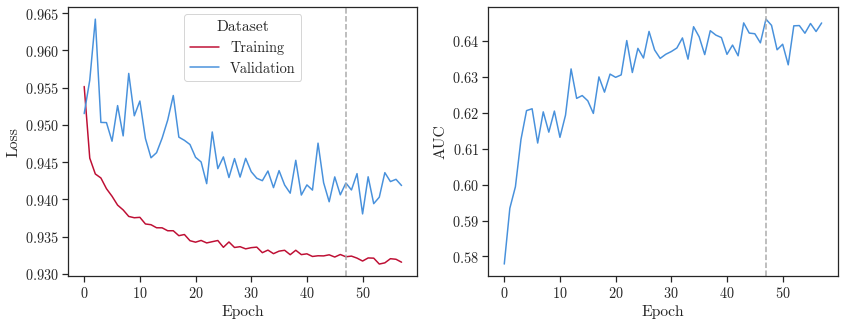

In [77]:
downsample_dir = os.path.join(model_dir, 'downsample')
downsample_files = [ f for f in os.listdir(downsample_dir) if 'csv' in f ]

data = None
for file in downsample_files:
    with open(os.path.join(downsample_dir, file), 'r') as f:
        downsample_amount = int(file.split('-')[1].split('_')[0])
        if downsample_amount == 1:
            df = pd.read_csv(f)
            data = df
            break

# Cut off data past maximum val_auc
idx_max = data['val_auc'].idxmax()
#data = data.iloc[:idx_max+1]

# Combine loss and val_loss into one dataframe with one loss column, separated by category
data_loss = data[['epoch', 'loss', 'val_loss']].copy()
data_loss = data_loss.melt(id_vars=['epoch'], value_vars=['loss', 'val_loss'], var_name='Dataset', value_name='loss_value')
data_loss['Dataset'] = data_loss['Dataset'].replace({'loss': 'Training', 'val_loss': 'Validation'})

@plot
def plot_loss_auc(data, data_loss, idx_max, size=1.0, height=0.6):
    fig, axs = plt.subplots(1, 2, figsize=fig_size(size, height), sharex=True, sharey=False)
    sns.lineplot(
        data=data_loss,
        x='epoch',
        y='loss_value',
        hue='Dataset',
        ax=axs[0],
    )
    sns.lineplot(
        data=data,
        x='epoch',
        y='val_auc',
        ax=axs[1],
        color=sns.color_palette()[1],
    )

    axs[0].axvline(x=idx_max, color='#aaaaaa', linestyle='--')
    axs[1].axvline(x=idx_max, color='#aaaaaa', linestyle='--')

    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('AUC')

    plt.tight_layout()

plot_loss_auc(data, data_loss, idx_max, output_pdf="training-validation-curves.pdf", show=True)

## roc-base.pdf, fpr-fnr-base.pdf

In [19]:
tfrecord_base = '2023-06-12'
embeddings = load_embeddings('days--1', [ f'{tfrecord_base}_0.tfrecord' ])[0]
labels = load_labels([ f'{tfrecord_base}_0.tfrecord' ])[0]

100%|██████████| 1/1 [00:00<00:00, 1013.61it/s]


In [20]:
distances = get_distances_numpy(embeddings)
distances_same, distances_diff = get_distances_same_diff(distances, labels)
df_statistical = get_statistical_data(distances_same, distances_diff, resolution=100)

100%|██████████| 100/100 [00:11<00:00,  8.56it/s]


In [42]:
# Save df_statistical
df_statistical.to_csv(os.path.join(results_dir, 'df_statistical.csv'), index=False)

In [78]:
# Load df_statistical
df_statistical = pd.read_csv(os.path.join(results_dir, 'df_statistical.csv'))

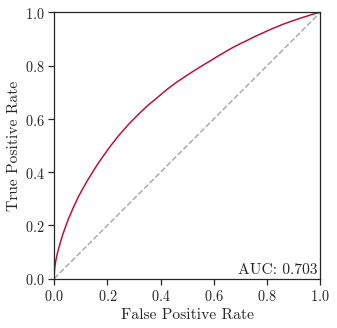

In [82]:
plot_roc(df_statistical, size=0.4, output_pdf='roc-base.pdf')

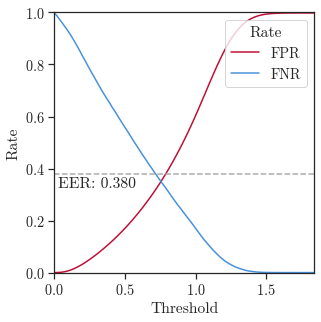

In [83]:
eer = find_eer(distances_same, distances_diff)
plot_fpr_fnr(df_statistical, eer, size=0.391, output_pdf='fpr-fnr-base.pdf')

## roc-mean.pdf

In [17]:
nums_anchors = [ 1, 2, 4, 8, 16, 32, 64 ]

In [ ]:
tfrecord_base = '2023-06-12'
start_index = tfrecord_files.index([ f for f in tfrecord_files if tfrecord_base in f ][0])

num_files = 2

embeddings = load_embeddings('days--1', tfrecord_files[start_index:start_index+num_files], verbose=False)
embeddings = np.concatenate(embeddings)
labels = load_labels(tfrecord_files[start_index:start_index+num_files], verbose=False)
labels = np.concatenate(labels)

dfs_mean, dfs_min, aucs_mean, aucs_min, eers_mean, eers_min = get_roc_data(embeddings, labels, nums_anchors, 10)

 88%|████████▊ | 7/8 [05:24<00:46, 46.29s/it]


In [73]:
for i, (eer, auc) in enumerate(zip(eers_mean, aucs_mean)):
    print(f"{nums_anchors[i]:2d} anchors: EER {eer:.3f}, AUC {auc:.3f}")

 1 anchors: EER 0.365, AUC 0.686
 2 anchors: EER 0.335, AUC 0.719
 4 anchors: EER 0.318, AUC 0.745
 8 anchors: EER 0.306, AUC 0.762
16 anchors: EER 0.300, AUC 0.769
32 anchors: EER 0.277, AUC 0.795
64 anchors: EER 0.281, AUC 0.800


In [61]:
# Save dfs_mean
df_mean = pd.concat(dfs_mean)
df_mean.to_csv(os.path.join(results_dir, 'dfs_mean.csv'), index=False)

In [18]:
# Load dfs_mean
df_mean = pd.read_csv(os.path.join(results_dir, 'dfs_mean.csv'))
dfs_mean = []
for n in nums_anchors:
    dfs_mean.append(df_mean[df_mean['Samples per test'] == n])

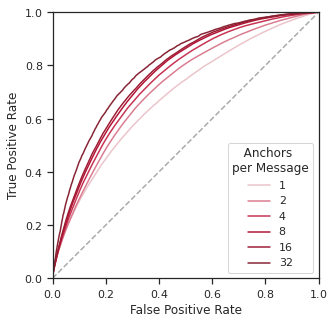

In [19]:
plot_roc_multiple(dfs_mean[:-1], hue_label="   Anchors\nper Message", size=0.4, output_pdf="roc-mean.pdf")

## dataset-size.pdf, dataset-offset.pdf, heatmap-auc.pdf, heatmap-eer.pdf

### Data Processing

In [39]:
model_names = [ f'days-{i}' for i in [1, 2, 4, 8, 16, 32, 64, -1] ]

In [ ]:
# Get average timestamp of initial training data

tfrecord_start = '2023-06-12'
ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, f'{tfrecord_start}_0.tfrecord'), all_features=True, shuffle=False)
timestamp_start = np.array([ ts for ts in ds_t.map(lambda x: x['timestamp']) ]).mean()

del ds_t

timestamp_start

2024-08-28 15:09:53.177356: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-28 15:09:54.319751: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5548 MB memory:  -> device: 0, name: NVIDIA TITAN V, pci bus id: 0000:61:00.0, compute capability: 7.0


1.6864980654566868e+18

In [ ]:
timestamps = compute_timestamps(tfrecord_files)
timestamps_days = (np.array(timestamps) - timestamp_start) / (1e9 * 24 * 60 * 60)

100%|██████████| 253/253 [01:33<00:00,  2.70it/s]


In [ ]:
embeddings = np.zeros((len(tfrecord_files), 5000, 512), dtype=float) #load_embeddings(model_name, tfrecord_files)
labels = load_labels(tfrecord_files)

100%|██████████| 253/253 [00:00<00:00, 4869.96it/s]


#### Anchors from Same Dataset

In [ ]:
def compute_time_data(index):
    distances = get_distances_numpy(embeddings[index])
    distances_same, distances_diff = get_distances_same_diff(distances, labels[index])
    df_statistical = get_statistical_data(distances_same, distances_diff, resolution=100, verbose=False)

    auc = roc_auc(df_statistical)
    eer = find_eer(distances_same, distances_diff)

    return (tfrecord_files[index], timestamps_days[index], auc, eer)

In [ ]:
time_datas = {}
for model_name in tqdm(model_names):
    embeddings = load_embeddings(model_name, tfrecord_files, verbose=False)
    with Pool(processes=32) as pool:
        time_datas[model_name] = pool.map(compute_time_data, range(len(tfrecord_files)))

100%|██████████| 1/1 [02:55<00:00, 175.64s/it]


In [ ]:
# Save time_datas
with open(os.path.join(results_dir, 'time_datas.pickle'), 'wb') as f:
    pickle.dump(time_datas, f)

#### Anchors Offset from Data

In [ ]:
def compute_time_data_with_offset(index, offset, epsilon=0.5):
    if abs(timestamps_days[index + offset] - timestamps_days[index] - offset) > epsilon:
        auc = None
        eer = None

    else:
        embeddings_combined = np.concatenate([embeddings[index], embeddings[index + offset]], axis=0)
        distances = get_distances_numpy(embeddings_combined)
        distances_same, distances_diff = get_distances_same_diff_a_b(distances, labels[index], labels[index + offset])
        try:
            df_statistical = get_statistical_data(distances_same, distances_diff, resolution=100, verbose=False)

            auc = roc_auc(df_statistical)
            eer = find_eer(distances_same, distances_diff)
        except ValueError:
            auc = None
            eer = None

    return (tfrecord_files[index], timestamps_days[index], auc, eer)

In [ ]:
offsets = [1, 2, 4, 8, 16, 32]

time_datas_offsets = {}
for model_name in tqdm(model_names):
    embeddings = load_embeddings(model_name, tfrecord_files, verbose=False)

    time_datas_m = {}
    for offset in tqdm(offsets, leave=False):
        with Pool(processes=32) as pool:
            time_datas_m[offset] = pool.map(functools.partial(compute_time_data_with_offset, offset=offset), range(len(tfrecord_files) - offset))

    time_datas_offsets[model_name] = time_datas_m

100%|██████████| 1/1 [32:58<00:00, 1978.53s/it]


In [ ]:
# Save time_datas_offsets
with open(os.path.join(results_dir, 'time_datas_offsets.pickle'), 'wb') as f:
    pickle.dump(time_datas_offsets, f)

### Plotting

In [85]:
# Load time_datas
with open(os.path.join(results_dir, 'time_datas.pickle'), 'rb') as f:
    time_datas = pickle.load(f)

# Load time_datas_offsets
with open(os.path.join(results_dir, 'time_datas_offsets.pickle'), 'rb') as f:
    time_datas_offsets = pickle.load(f)

In [86]:
# Turn time_datas from dict[str, list[tuple]] into list[tuple], adding model_name to each tuple
time_datas_list = []
for model_name in time_datas.keys():
    for time_data in time_datas[model_name]:
        time_datas_list.append((int(model_name.split('-', 1)[1]),) + time_data)

df_time = pd.DataFrame(time_datas_list, columns=['days', 'tfrecord', 'timestamp', 'auc', 'eer'])

# Categorical column
df_time['days_cat'] = pd.Categorical(df_time['days'], categories=df_time['days'].unique(), ordered=True)
df_time['days_cat'] = df_time['days_cat'].cat.rename_categories({-1: 'All'})
# Reorder categories so "All" is last
df_time['days_cat'] = df_time['days_cat'].cat.reorder_categories([i for i in df_time['days_cat'].cat.categories if i != 'All'] + ['All'])

df_time

,days,tfrecord,timestamp,auc,eer,days_cat
0,-1,2023-05-12_0.tfrecord,-31.014840,0.716530,0.341255,All
1,-1,2023-05-13_0.tfrecord,-30.019162,0.708889,0.347227,All
2,-1,2023-05-14_0.tfrecord,-29.019354,0.723791,0.336865,All
3,-1,2023-05-15_0.tfrecord,-28.017009,0.718147,0.340449,All
4,-1,2023-05-16_0.tfrecord,-27.014134,0.716379,0.342685,All
...,...,...,...,...,...,...
2019,64,2024-04-20_0.tfrecord,313.139135,0.693495,0.358903,64
2020,64,2024-04-21_0.tfrecord,314.138693,0.678183,0.370028,64
2021,64,2024-04-22_0.tfrecord,315.140128,0.692016,0.359136,64
2022,64,2024-04-23_0.tfrecord,316.141481,0.692029,0.359749,64


In [87]:
time_datas_offsets_list = []
for model_name in time_datas_offsets.keys():
    for offset in time_datas_offsets[model_name].keys():
        for time_data in time_datas_offsets[model_name][offset]:
            time_datas_offsets_list.append((int(model_name.split('-', 1)[1]), offset) + time_data)
df_time_offset = pd.DataFrame(time_datas_offsets_list, columns=['days', 'offset', 'tfrecord', 'timestamp', 'auc', 'eer'])

# Categorical column
df_time_offset['days_cat'] = pd.Categorical(df_time_offset['days'], categories=df_time_offset['days'].unique(), ordered=True)
df_time_offset['offset_cat'] = pd.Categorical(df_time_offset['offset'], categories=df_time_offset['offset'].unique(), ordered=True)

df_time_offset

,days,offset,tfrecord,timestamp,auc,eer,days_cat,offset_cat
0,-1,1,2023-05-12_0.tfrecord,-31.014840,0.573521,0.447046,-1,1
1,-1,1,2023-05-13_0.tfrecord,-30.019162,0.562958,0.456699,-1,1
2,-1,1,2023-05-14_0.tfrecord,-29.019354,0.579784,0.444189,-1,1
3,-1,1,2023-05-15_0.tfrecord,-28.017009,0.577739,0.444829,-1,1
4,-1,1,2023-05-16_0.tfrecord,-27.014134,0.571791,0.447435,-1,1
...,...,...,...,...,...,...,...,...
11635,64,32,2024-03-19_0.tfrecord,281.122539,0.772256,0.115654,64,32
11636,64,32,2024-03-20_0.tfrecord,282.126207,0.227215,0.720000,64,32
11637,64,32,2024-03-21_0.tfrecord,283.126467,0.336925,0.562408,64,32
11638,64,32,2024-03-22_0.tfrecord,284.127500,0.605432,0.404761,64,32


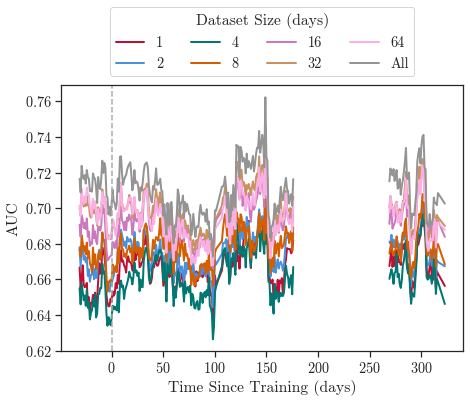

In [88]:
@plot
def plot_dataset_size(df_time, size=1.0, height=1.0):
    fig, ax = plt.subplots(figsize=fig_size(size, height))

    sns.lineplot(
        data=df_time[df_time['timestamp'] <= 200],
        x='timestamp',
        y='auc',
        hue='days_cat',
        linewidth=2,
        ax=ax,
    )
    sns.lineplot(
        data=df_time[df_time['timestamp'] >= 250],
        x='timestamp',
        y='auc',
        hue='days_cat',
        linewidth=2,
        ax=ax,
        legend=False
    )

    ax.set_xlabel('Time Since Training (days)')
    ax.set_ylabel('AUC')

    ax.axvline(0, color='#aaaaaa', linestyle='--')

    # Set legend label
    ax.legend(title='Dataset Size (days)', ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.32))

plot_dataset_size(df_time, size=0.6, height=1.0, output_pdf="dataset-size.pdf")

In [89]:
@plot
def plot_dataset_offset(df_time_offset, days: list[int], size=1.0, height=0.55):
    df_temp = df_time_offset[df_time_offset['days'].isin(days)].copy()
    df_temp['days_cat'] = pd.Categorical(df_temp['days'], categories=df_temp['days'].unique(), ordered=True)
    # Order to match days
    df_temp['days_cat'] = df_temp['days_cat'].cat.reorder_categories(days)
    df_temp['days_cat'] = df_temp['days_cat'].map(lambda x: f'{x} day{"s" if x != 1 else ""}')
    df_temp['days_cat'] = df_temp['days_cat'].replace({"-1 days": 'All'})
    df_temp['Anchor Offset (days)'] = pd.Categorical(df_temp['offset_cat'], categories=list(df_temp['offset_cat'].unique()), ordered=True)

    grid = sns.relplot(
        data=df_temp[df_temp['timestamp'] <= 200],
        x='timestamp',
        y='auc',
        hue='Anchor Offset (days)',
        col='days_cat',
        kind='line',
        linewidth=2,
        facet_kws={
            'sharex': True,
            'sharey': True,
        },
    )
    # Set size
    grid.figure.set_size_inches(fig_size(size, height))

    # Plot second half of data
    for i, d in enumerate(days):
        # Get axis i
        ax = grid.axes[0][i]
        sns.lineplot(
            data=df_temp[(df_temp['timestamp'] >= 250) & (df_temp['days'] == d)],
            x='timestamp',
            y='auc',
            hue='Anchor Offset (days)',
            linewidth=2,
            legend=False,
            ax=ax
        )

    grid.set_axis_labels('Time Since Training (days)', 'AUC')
    grid.set_titles("Dataset Size: {col_name}")

    sns.despine(top=False, right=False)

    for ax in grid.axes.flatten():
        ax.axvline(0, color='#aaaaaa', linestyle='--')
        ax.axhline(0.5, color='#aaaaaa', linestyle='--')

    sns.move_legend(grid, 'upper center', bbox_to_anchor=(0.45, 1.16), frameon=True, ncols=6)

/tmp/ipykernel_58000/2296036651.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_temp['days_cat'] = df_temp['days_cat'].replace({"-1 days": 'All'})


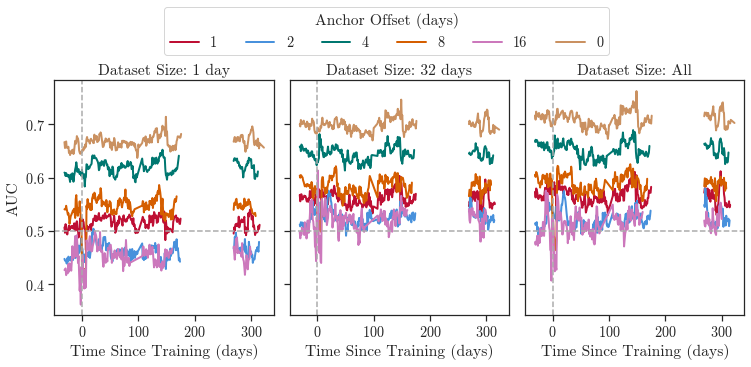

In [90]:
# Add data from df_time to df_time_offset, with offset=0 and offset_cat=0
df_temp = df_time.copy()
df_temp['offset'] = 0
df_temp['offset_cat'] = 0
df_plot = pd.concat([df_time_offset, df_temp])
df_plot.reset_index(drop=True, inplace=True)
categories = df_plot['offset'].unique()
categories.sort()
df_plot['offset_cat'] = pd.Categorical(df_plot['offset'], categories=categories, ordered=True)
df_plot = df_plot[df_plot['offset_cat'] != 32]
plot_dataset_offset(df_plot, [1, 32, -1], output_pdf="dataset-offset.pdf")

In [91]:
df_time_mean = df_time.groupby('days')[['auc', 'eer']].mean()
df_time_offset_mean = df_time_offset.groupby(['days', 'offset'])[['auc', 'eer']].mean()

# Merge the two together (setting df_time_mean to have offset 0 in new index column)
df_time_mean['offset'] = 0
df_time_mean = df_time_mean.set_index('offset', append=True)
df_mean = pd.concat([df_time_mean, df_time_offset_mean])
df_mean = df_mean.sort_index()

# Change index sorting so "All" is last
df_mean = df_mean.rename(index={-1: 'All'})
df_mean = df_mean.loc[[i for i in df_mean.index if i[0] != 'All'] + [i for i in df_mean.index if i[0] == 'All']]

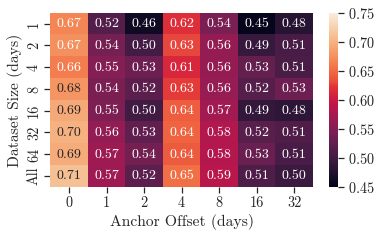

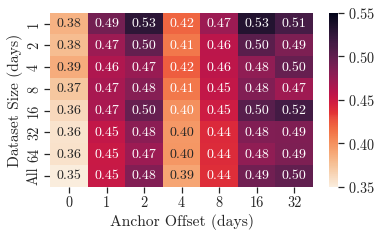

In [92]:
@plot
def plot_heatmap(df_mean, variable='auc', invert=False, size=1.0, height=0.8, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=fig_size(size, height))
    cmap = palette_gradient if not invert else palette_gradient.reversed()
    sns.heatmap(df_mean[variable].unstack(), annot=True, fmt=".2f", cmap=cmap, ax=ax, annot_kws={"fontsize":14}, vmin=vmin, vmax=vmax)
    ax.set_xlabel('Anchor Offset (days)')
    ax.set_ylabel('Dataset Size (days)')

plot_heatmap(df_mean, variable='auc', vmin=0.45, vmax=0.75, size=0.49, output_pdf="heatmap-auc.pdf")
plot_heatmap(df_mean, variable='eer', vmin=0.35, vmax=0.55, invert=True, size=0.49, output_pdf="heatmap-eer.pdf")

## offset-heatmap.pdf

In [17]:
labels = load_labels(tfrecord_files)
timestamps = compute_timestamps(tfrecord_files, days=True, start_date='2023-06-12')

  0%|          | 0/253 [00:00<?, ?it/s]2025-05-07 10:21:59.884080: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-05-07 10:21:59.884124: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: punk
2025-05-07 10:21:59.884288: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: punk
2025-05-07 10:21:59.884486: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 570.133.20
2025-05-07 10:21:59.884517: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 570.86.15
2025-05-07 10:21:59.884526: E tensorflow/stream_executor/cuda/cuda_diagnostics.cc:313] kernel version 570.86.15 does not match DSO version 570.133.20 -- cannot find working devices in this configuration
2025-05-07 10:21:59.885219: I tensorflow/core/platform/cpu_

In [18]:
offset_counts = np.zeros((labels.shape[0], labels.shape[0]), dtype=int)
# Given lists of labels[i], labels[j], get the number of same and different pairs
for i in tqdm(range(labels.shape[0])):
    for j in range(i, labels.shape[0]):
        offset_count = np.sum(np.sum(labels[i] == labels[j][:, None]))
        offset_counts[i, j] = offset_count
        offset_counts[j, i] = offset_count

100%|██████████| 253/253 [22:33<00:00,  5.35s/it]


In [19]:
def convert_data_to_timestamps(data, timestamps, fill_nan=False):
    timestamps_int = np.round(timestamps).astype(int)
    timestamps_range = max(timestamps_int) - min(timestamps_int) + 1
    data_timestamped = np.zeros((timestamps_range, timestamps_range), dtype=data.dtype)
    for i in range(labels.shape[0]):
        if i > 0 and timestamps_int[i] - timestamps_int[i-1] > 2:
            continue
        if i < labels.shape[0] - 1 and timestamps_int[i+1] - timestamps_int[i] > 2:
            continue
        for j in range(i, labels.shape[0]):
            if j > 0 and timestamps_int[j] - timestamps_int[j-1] > 2:
                continue
            if j < labels.shape[0] - 1 and timestamps_int[j+1] - timestamps_int[j] > 2:
                continue
            data_timestamped[timestamps_int[i] - min(timestamps_int), timestamps_int[j] - min(timestamps_int)] = data[i, j]
            data_timestamped[timestamps_int[j] - min(timestamps_int), timestamps_int[i] - min(timestamps_int)] = data[j, i]

    # Trim down offset_counts_timestamped to remove all-zero rows/columns on the edges
    row_sum = np.sum(data_timestamped, axis=1)
    col_sum = np.sum(data_timestamped, axis=0)
    row_nonzero = np.nonzero(row_sum)
    col_nonzero = np.nonzero(col_sum)
    data_timestamped_trimmed = data_timestamped[row_nonzero[0][0]:row_nonzero[0][-1]+1, col_nonzero[0][0]:col_nonzero[0][-1]+1]

    if fill_nan:
        # replace zeros with NaN
        data_timestamped_trimmed[data_timestamped_trimmed == 0] = np.nan

    return data_timestamped_trimmed

In [23]:
offset_counts_timestamped = convert_data_to_timestamps(offset_counts, timestamps)
# Save offset_counts_timestamped
np.save(os.path.join(results_dir, 'offset_counts_timestamped.npy'), offset_counts_timestamped)

In [57]:
# Load offset_counts_timestamped
offset_counts_timestamped = np.load(os.path.join(results_dir, 'offset_counts_timestamped.npy'))

In [58]:
@plot
def plot_offset_heatmap(data, log_scale=True, cbar_label=None, size=1.0):
    plt.figure(figsize=fig_size(size, 1.0))
    color = palette_gradient
    color.set_bad('black')
    sns.heatmap(
        data,
        square=True,
        rasterized=True,
        norm=LogNorm() if log_scale else None,
        cmap=color,
    )

    plt.xlabel('Time Since Dataset Start (days)')
    plt.ylabel('Time Since Dataset Start (days)')

    plt.xticks(np.arange(0, data.shape[1], 40), np.arange(0, data.shape[1], 40))
    plt.yticks(np.arange(0, data.shape[1], 40), np.arange(0, data.shape[1], 40))

    # Move x ticks to the top
    plt.gca().xaxis.set_ticks_position('top')
    plt.gca().xaxis.set_label_position('top')
    # Add space below x axis label
    plt.gca().xaxis.labelpad = 10

    # Add space above cbar label
    cbar = plt.gcf().axes[-1]
    cbar.set_ylabel(cbar_label or 'Matching Pairs Count', labelpad=10)

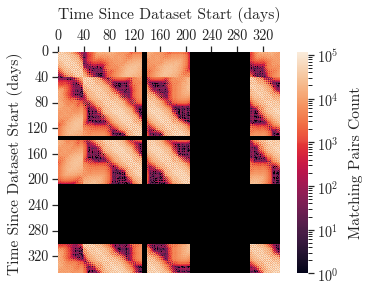

In [93]:
plot_offset_heatmap(offset_counts_timestamped, size=0.5, output_pdf="offset-heatmap.pdf")

## auc-properties-weather.pdf, auc-properties.pdf

### Compute Data

In [ ]:
def compute_average_properties(tfrecord_files, properties: list[str], verbose=True):
    out = {}
    for p in properties:
        out[p] = []

    for tfrecord_file in tqdm(tfrecord_files, disable=not verbose):
        ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, tfrecord_file), all_features=True, shuffle=False)

        for p in properties:
            p_mean = np.array([ x for x in ds_t.map(lambda x: x[p]) ]).mean(axis=0)

            out[p].append(p_mean)

        del ds_t

    return out

In [23]:
property_names = [
    'cloudcover',
    'confidence',
    'distance',
    'humidity',
    'level',
    'magnitude',
    'noise',
    'precip',
    'solarradiation',
    'temp',
    'scale'
]

property_map = {
    'cloudcover': 'Cloud Cover (%)',
    'confidence': 'Confidence',
    'distance': 'Distance (km)',
    'humidity': 'Humidity (%)',
    'level': 'Level',
    'magnitude': 'Magnitude',
    'noise': 'Noise',
    'precip': 'Precipitation (mm)',
    'solarradiation': 'Solar Radiation (W/m^2)',
    #'temp': 'Temperature (°C)',
    'temp': 'Temperature ($\degree$C)',
    'scale': 'Scale'
}

In [ ]:
average_properties = compute_average_properties(tfrecord_files, property_names)

average_properties['scale_1'] = [ p[0] for p in average_properties['scale'] ]
average_properties['scale_2'] = [ p[1] for p in average_properties['scale'] ]
del average_properties['scale']

In [ ]:
# Save average_properties
with open(os.path.join(results_dir, 'average_properties.pickle'), 'wb') as f:
    pickle.dump(average_properties, f)

### Plotting

In [18]:
# Load average_properties
with open(os.path.join(results_dir, 'average_properties.pickle'), 'rb') as f:
    average_properties = pickle.load(f)

# Load time_datas
with open(os.path.join(results_dir, 'time_datas.pickle'), 'rb') as f:
    time_datas = pickle.load(f)

In [19]:
# Turn time_datas from dict[str, list[tuple]] into list[tuple], adding model_name to each tuple
time_datas_list = []
for model_name in time_datas.keys():
    for time_data in time_datas[model_name]:
        time_datas_list.append((int(model_name.split('-', 1)[1]),) + time_data)

df_time = pd.DataFrame(time_datas_list, columns=['days', 'tfrecord', 'timestamp', 'auc', 'eer'])

# Categorical column
df_time['days_cat'] = pd.Categorical(df_time['days'], categories=df_time['days'].unique(), ordered=True)
df_time['days_cat'] = df_time['days_cat'].cat.rename_categories({-1: 'All'})
# Reorder categories so "All" is last
df_time['days_cat'] = df_time['days_cat'].cat.reorder_categories([i for i in df_time['days_cat'].cat.categories if i != 'All'] + ['All'])

In [20]:
# Add each property to df_time
for i in range(len(tfrecord_files)):
    for p in average_properties.keys():
        df_time.loc[df_time['tfrecord'] == tfrecord_files[i], p] = average_properties[p][i]

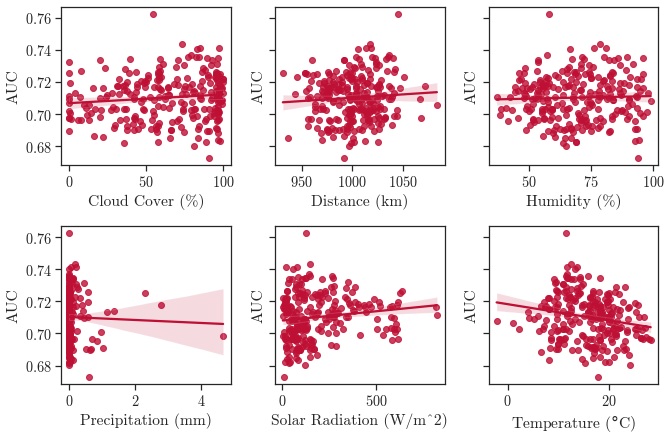

In [26]:
# Scatter plot, AUC vs property
@plot
def plot_properties_reduced(size=1.0, height=1.0):
    fig, axs = plt.subplots(2, 3, figsize=fig_size(size, height), sharex=False, sharey=True)
    axs_flat = axs.flatten()
    for i, prop in enumerate([ list(average_properties.keys())[i] for i in [0, 2, 3, 7, 8, 9] ]):
        ax = axs_flat[i]

        sns.regplot(
            data=df_time[df_time['days'] == -1],
            x=prop,
            y='auc',
            ax=ax,
        )

        ax.set_xlabel(property_map.get(prop, prop))
        ax.set_ylabel('AUC')

        plt.tight_layout()

plot_properties_reduced(size=0.8, output_pdf="auc-properties-weather.pdf")

In [79]:
model_name = 'days--1'
embeddings = load_embeddings(model_name, tfrecord_files, verbose=False)
labels = load_labels(tfrecord_files, verbose=False)

index = 0

In [80]:
def load_properties(tfrecord_files, property_names: list[str], verbose=True):
    out = []

    for tfrecord_file in tqdm(tfrecord_files, disable=not verbose):
        ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, tfrecord_file), all_features=True, shuffle=False)

        out_t = {}

        for p in property_names:
            p_array = np.array([ x for x in ds_t.map(lambda x: x[p]) ])

            out_t[p] = p_array

        del ds_t

        out.append(out_t)

    return out

properties = load_properties(tfrecord_files[:60], property_names)

100%|██████████| 60/60 [04:41<00:00,  4.70s/it]


In [81]:
start_date = '2023-06-12'
start_index = tfrecord_files.index([ f for f in tfrecord_files if start_date in f ][0])

def compute_filtered_results(
        embeddings,
        labels,
        properties,
        property_names,
        start_index,
        num_files=1,
        min_entries=100,
        max_entries=5000
    ):
    results = []

    embeddings_array = embeddings[start_index:start_index+num_files].reshape(-1, 512)
    labels_array = labels[start_index:start_index+num_files].reshape(-1)

    for property in tqdm(property_names):
        property_list = []
        for i in range(start_index, start_index+num_files):
            property_list.append(properties[i][property])
        property_array = np.array(property_list).reshape(-1)

        for percentile in range(10, 101, 10):
            # Find the threshold such that we get the correct fraction of the dataset
            threshold_l = np.percentile(property_array, percentile - 10)
            threshold_r = np.percentile(property_array, percentile)
            property_filter = (property_array >= threshold_l) & (property_array < threshold_r)

            if np.sum(property_filter) < min_entries:
                continue
            if np.sum(property_filter) > max_entries:
                # Reduce to max_entries
                indices = np.where(property_filter)[0]
                np.random.shuffle(indices)
                property_filter[indices[max_entries:]] = False

            embeddings_filtered = embeddings_array[property_filter]
            labels_filtered = labels_array[property_filter]
            if len(labels_filtered) == 0:
                continue
            distances = get_distances_numpy(embeddings_filtered)
            distances_same, distances_diff = get_distances_same_diff(distances, labels_filtered)
            df_statistical = get_statistical_data(distances_same, distances_diff, resolution=100, verbose=False)
            auc = roc_auc(df_statistical)
            eer = find_eer(distances_same, distances_diff)

            results.append((property, percentile, threshold_l, threshold_r, auc, eer))

    return results

In [82]:
results = compute_filtered_results(
    embeddings,
    labels,
    properties,
    property_names[:-1],
    start_index,
    num_files=16,
)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [15:53<00:00, 95.32s/it]


In [90]:
df_results = pd.DataFrame(results, columns=['property', 'percentile', 'threshold_l', 'threshold_r', 'auc', 'eer'])
# Save df_results
df_results.to_csv(os.path.join(results_dir, 'df_auc_properties.csv'), index=False)

In [27]:
# Load df_results
df_results = pd.read_csv(os.path.join(results_dir, 'df_auc_properties.csv'))

In [28]:
@plot
def plot_df_results(df_results, size=1.0):
    df_t = df_results.copy()

    df_t['Property'] = df_t['property'].map(property_map)

    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=fig_size(size, square=True), sharex=True, sharey=True)
    for i, property in enumerate(df_t['Property'].unique()):
        ax = axs[i // 3, i % 3]
        sns.lineplot(
            data=df_t[df_t['Property'] == property],
            x='percentile',
            y='auc',
            ax=ax
        )
        ax.set_title(property)

        # Rename x-axis
        ax.set_xlabel("Dataset Percentile")
        ax.set_ylabel("AUC")

        plt.tight_layout()

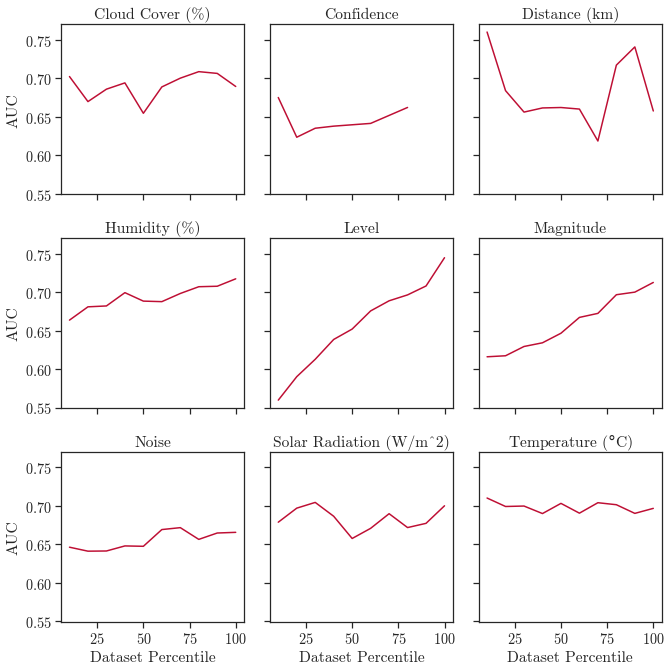

In [29]:
plot_df_results(df_results, size=0.8, output_pdf="auc-properties.pdf")

## downsample.pdf

In [94]:
downsample_dir = os.path.join(model_dir, 'downsample')
downsample_files = [ f for f in os.listdir(downsample_dir) if 'csv' in f ]

downsample_data = []
for file in downsample_files:
    with open(os.path.join(downsample_dir, file), 'r') as f:
        downsample_amount = int(file.split('-')[1].split('_')[0])
        df = pd.read_csv(f)
        downsample_data.append((downsample_amount, df['val_auc'].max()))

downsample_data = sorted(downsample_data, key=lambda x: x[0])
downsample_data = [ max([ (i, auc) for i, auc in downsample_data if i == 1 ]) ] + [ (i, auc) for i, auc in downsample_data if i != 1 ]

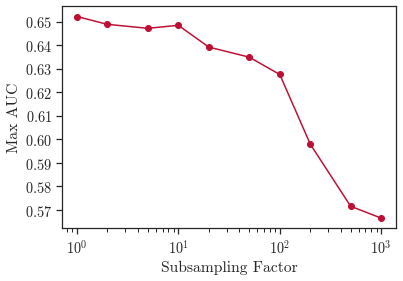

In [95]:
@plot
def plot_downsample(downsample_data):
    fig, ax = plt.subplots(figsize=fig_size(0.5, 1.0))
    downsample_data = np.array(downsample_data)
    plt.plot(downsample_data[:, 0], downsample_data[:, 1], marker='o')
    plt.xlabel('Subsampling Factor')
    plt.ylabel('Max AUC')
    plt.xscale('log')
    plt.yticks(np.arange(0.57, 0.65, 0.01))
    #plt.grid()

plot_downsample(downsample_data, output_pdf="downsample.pdf")

## roc-anchor-removed-transmitters.pdf

In [16]:
labels = load_labels(tfrecord_files)

100%|██████████| 253/253 [00:00<00:00, 1880.77it/s]


In [17]:
start_date = '2023-06-12'
label_index = tfrecord_files.index([ f for f in tfrecord_files if start_date in f ][0])
labels_i = labels[label_index:label_index+5].flatten()
labels_unique, labels_counts = np.unique(labels_i, return_counts=True)
# Sort both by labels_counts
labels_unique = labels_unique[np.argsort(labels_counts)]
labels_counts = labels_counts[np.argsort(labels_counts)]
labels_filter = labels_unique[::2]
labels_filter = np.sort(labels_filter)

print(f"Number of removed labels: {len(labels_filter)}")

Number of removed labels: 422


In [18]:
test_date = '2023-06-12'

ds_seen = TFRecordLoaderFull.from_file(
    os.path.join(data_dir, f'{test_date}_0.tfrecord'),
    all_features=True,
    shuffle=False,
    filter_predicate = lambda x: not tf.reduce_any(tf.equal(x['id_cell'], labels_filter))
)
ds_unseen = TFRecordLoaderFull.from_file(
    os.path.join(data_dir, f'{test_date}_0.tfrecord'),
    all_features=True,
    shuffle=False,
    filter_predicate = lambda x: tf.reduce_any(tf.equal(x['id_cell'], labels_filter))
)
samples_seen = np.array([ s['sample'] for s in ds_seen ])
labels_seen = np.array([ s['id_cell'] for s in ds_seen ])
samples_unseen = np.array([ s['sample'] for s in ds_unseen ])
labels_unseen = np.array([ s['id_cell'] for s in ds_unseen ])

del ds_seen, ds_unseen

2025-09-03 16:08:07.110948: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-03 16:08:07.347381: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22808 MB memory:  -> device: 0, name: NVIDIA TITAN RTX, pci bus id: 0000:82:00.0, compute capability: 7.5


In [19]:
model = load_model('days-16-extensibility')

embeddings_seen = model.model.predict(samples_seen)[0]
distances_seen = get_distances_numpy(embeddings_seen)
distances_same_seen, distances_diff_seen = get_distances_same_diff(distances_seen, labels_seen)
df_statistical_seen = get_statistical_data(distances_same_seen, distances_diff_seen, resolution=100)
auc_seen = roc_auc(df_statistical_seen)
eer_seen = find_eer(distances_same_seen, distances_diff_seen)

embeddings_unseen = model.model.predict(samples_unseen)[0]
distances_unseen = get_distances_numpy(embeddings_unseen)
distances_same_unseen, distances_diff_unseen = get_distances_same_diff(distances_unseen, labels_unseen)
df_statistical_unseen = get_statistical_data(distances_same_unseen, distances_diff_unseen, resolution=100)
auc_unseen = roc_auc(df_statistical_unseen)
eer_unseen = find_eer(distances_same_unseen, distances_diff_unseen)

del model

print(f"Seen: AUC: {auc_seen}, EER: {eer_seen}")
print(f"Unseen: AUC: {auc_unseen}, EER: {eer_unseen}")

2025-09-03 16:08:15.926302: I tensorflow/stream_executor/cuda/cuda_dnn.cc:366] Loaded cuDNN version 8902
2025-09-03 16:08:16.043032: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
100%|██████████| 100/100 [00:02<00:00, 40.54it/s]


Seen: AUC: 0.6722770042663487, EER: 0.3797295428202654
Unseen: AUC: 0.6814272087117943, EER: 0.37027246811315995


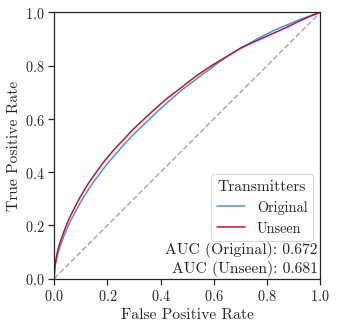

In [96]:
plot_roc_a_b(df_statistical_seen, df_statistical_unseen, "Original", "Unseen", legend_title="Transmitters", size=0.4, output_pdf="roc-anchor-removed-transmitters.pdf")

## roc-transferability.pdf

In [112]:
dataset_files = {
    'UK': '2023-06-12_0.tfrecord',
    'Germany': 'germany/2023-04-01_0.tfrecord',
    'Switzerland': 'switzerland/2024-08-12_0.tfrecord',
}
datasets = list(dataset_files.keys())

samples = {}
labels = {}
for dataset, tfrecord_file in dataset_files.items():
    ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, tfrecord_file), all_features=True, shuffle=False)
    samples[dataset] = np.array([ x['sample'] for x in ds_t ])
    labels[dataset] = np.array([ x['id_cell'] for x in ds_t ])
    del ds_t

In [113]:
models = {
    'UK (Full)': 'days--1',
    'UK (Smaller)': 'days-8',
    'Switzerland': 'switzerland',
    'Combined': 'uk-switzerland',
}

results = {}

for model_dataset, model_name in tqdm(models.items()):
    model = load_model(model_name)

    embeddings = {}
    for dataset in datasets:
        embeddings[dataset] = model.model.predict(samples[dataset])[0]

    del model

    results[model_dataset] = {}
    for dataset, es in embeddings.items():
        distances = get_distances_numpy(es)
        distances_same, distances_diff = get_distances_same_diff(distances, labels[dataset])
        df_statistical = get_statistical_data(distances_same, distances_diff, resolution=100, verbose=False)
        auc = roc_auc(df_statistical)
        eer = find_eer(distances_same, distances_diff)
        results[model_dataset][dataset] = (df_statistical, auc, eer)

100%|██████████| 4/4 [13:43<00:00, 205.83s/it]


In [115]:
print("Training Data | Testing Data | AUC   | EER  ")
print("============================================")
for model_dataset, model_results in results.items():
    for dataset, (df, auc, eer) in model_results.items():
        print(f"{model_dataset:13} | {dataset:12} | {auc:.3f} | {eer:.3f}")

print()

for model_dataset, model_results in results.items():
    for dataset, (df, auc, eer) in model_results.items():
        print(f"{model_dataset:13} & {dataset:12} & {auc:.3f} & {eer:.3f} \\\\")

Training Data | Testing Data | AUC   | EER  
UK (Full)     | UK           | 0.703 | 0.351
UK (Full)     | Germany      | 0.536 | 0.473
UK (Full)     | Switzerland  | 0.620 | 0.410
UK (Smaller)  | UK           | 0.660 | 0.385
UK (Smaller)  | Germany      | 0.512 | 0.492
UK (Smaller)  | Switzerland  | 0.585 | 0.440
Switzerland   | UK           | 0.577 | 0.444
Switzerland   | Germany      | 0.564 | 0.458
Switzerland   | Switzerland  | 0.678 | 0.372
Combined      | UK           | 0.627 | 0.408
Combined      | Germany      | 0.524 | 0.481
Combined      | Switzerland  | 0.652 | 0.392

UK (Full)     & UK           & 0.703 & 0.351 \\
UK (Full)     & Germany      & 0.536 & 0.473 \\
UK (Full)     & Switzerland  & 0.620 & 0.410 \\
UK (Smaller)  & UK           & 0.660 & 0.385 \\
UK (Smaller)  & Germany      & 0.512 & 0.492 \\
UK (Smaller)  & Switzerland  & 0.585 & 0.440 \\
Switzerland   & UK           & 0.577 & 0.444 \\
Switzerland   & Germany      & 0.564 & 0.458 \\
Switzerland   & Switzerland  &

In [117]:
# Create one big DF with new columns for training/testing data
dfs = []
for model_dataset, model_results in results.items():
    for dataset, (df, auc, eer) in model_results.items():
        df_temp = df.copy()
        df_temp['Training Data'] = model_dataset
        df_temp['Testing Data'] = dataset
        dfs.append(df_temp)

df = pd.concat(dfs)
df.reset_index(drop=True, inplace=True)

# Save df
df.to_csv(os.path.join(results_dir, 'df_roc_transferability.csv'), index=False)

In [97]:
# Load df
df = pd.read_csv(os.path.join(results_dir, 'df_roc_transferability.csv'))

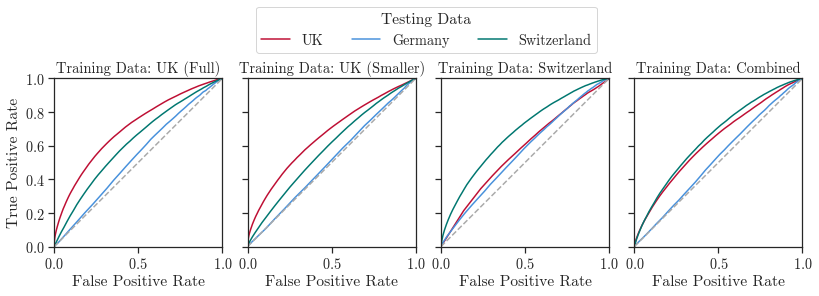

In [98]:
@plot
def plot_roc_multiple_2(df, size=1.0, height=0.5):
    grid = sns.relplot(
        kind='line',
        data=df,
        x='fpr',
        y='tpr',
        hue='Testing Data',
        col='Training Data',
    )
    # Add full spines
    sns.despine(top=False, right=False)

    # Force square aspect ratio
    for ax in grid.axes.flatten():
        ax.set_box_aspect(1)
    # Change labels
    grid.set_axis_labels('False Positive Rate', 'True Positive Rate')
    # Change titles
    grid.set_titles("Training Data: {col_name}", size=14.5)
    # Set size
    grid.figure.set_size_inches(fig_size(size, height))
    # Increase spacing between subplots
    grid.figure.subplots_adjust(wspace=0.15)

    # Draw diagonal line
    for ax in grid.axes.flatten():
        ax.plot([0, 1], [0, 1], color='#aaaaaa', linestyle='--')
        ax.set(xlim=(0, 1), ylim=(0, 1))

    # Change legend
    sns.move_legend(grid, 'upper center', bbox_to_anchor=(0.475, 1.1), frameon=True, ncols=3, title='Testing Data')

plot_roc_multiple_2(df, output_pdf="roc-transferability.pdf")

## roc-replay-mean.pdf, replay-dists.pdf

In [27]:
nums_anchors = [1, 2, 4, 8, 16, 32]

In [153]:
def get_id_cell(sat_id, sat_cell, num_cells=63):
    return (sat_id * num_cells) + sat_cell

db = Database(os.path.join(data_base, "db-replay.sqlite3"), 11000)
db.generate_arrays_noise()
samples_replay = db.samples_array.copy()
for i in range(samples_replay.shape[0]):
    samples_replay[i] -= np.min(samples_replay[i])
    samples_replay[i] /= np.max(samples_replay[i])
labels_replay = get_id_cell(db.ids_array.copy(), db.cells_array.copy())

del db

In [154]:
model = load_model("days--1")
embeddings_replay = model.model.predict(samples_replay)[0]
del model

In [155]:
embeddings = load_embeddings("days--1", tfrecord_files, verbose=False)
labels = load_labels(tfrecord_files, verbose=False)

In [156]:
def get_anchors_tests_a_b(labels_a, labels_b, num_anchors, n_splits):
    """
    Get the indices for the anchors and tests for two datasets.
    Anchors are taken from dataset a only, tests are taken from both datasets and returned separately.
    """

    labels_unique = np.unique(labels_a)

    anchors = dict()
    tests_a = dict()
    tests_b = dict()
    for label in labels_unique:
        indices_a = np.where(labels_a == label)[0]
        indices_b = np.where(labels_b == label)[0]
        if len(indices_a) <= num_anchors:
            continue
        ss = ShuffleSplit(n_splits=n_splits, test_size=num_anchors / len(indices_a), random_state=0)
        #indices_a = np.random.permutation(indices_a)
        #indices_b = np.random.permutation(indices_b)
        anchors[label] = []
        tests_a[label] = []
        tests_b[label] = []
        for test_index, anchor_index in ss.split(indices_a):
            anchors[label].append(indices_a[anchor_index])
            tests_a[label].append(indices_a[test_index])
            tests_b[label].append(indices_b)

    return anchors, tests_a, tests_b

def get_distances_a_b(anchors, tests_a, tests_b, offset, n_splits, distances):
    labels_unique = list(anchors.keys())

    distances_same_mean = []
    distances_diff_mean = []

    for label in tqdm(labels_unique):
        for i in range(n_splits):
            for index_test in tests_a[label][i]:
                dists = distances[anchors[label][i], index_test]
                distances_same_mean.append(np.mean(dists))

            for index_test in tests_b[label][i]:
                dists = distances[anchors[label][i], offset + index_test]
                distances_diff_mean.append(np.mean(dists))

    distances_same_mean = np.array(distances_same_mean)
    distances_diff_mean = np.array(distances_diff_mean)

    return (distances_same_mean, distances_diff_mean)

def get_roc_data_a_b(embeddings_a, labels_a, embeddings_b, labels_b, nums_anchors, n_splits):
    dfs_mean = []
    aucs_mean = []
    eers_mean = []
    for num_anchors in nums_anchors:
        embeddings = np.concatenate((embeddings_a, embeddings_b))
        distances = get_distances_numpy(embeddings)

        anchors, tests_a, tests_b = get_anchors_tests_a_b(labels_a, labels_b, num_anchors, n_splits)
        distances_same_mean, distances_diff_mean = get_distances_a_b(anchors, tests_a, tests_b, len(embeddings_a), n_splits, distances)
        dfs_mean.append(get_statistical_data(distances_same_mean, distances_diff_mean))

        aucs_mean.append(roc_auc(dfs_mean[-1]))
        eers_mean.append(find_eer(distances_same_mean, distances_diff_mean))

        dfs_mean[-1]['Samples per test'] = num_anchors

    return dfs_mean, aucs_mean, eers_mean

def get_ordered_dists(distances, embeddings_a, labels_a, embeddings_b, labels_b, num_anchors, n_splits):
    dists = []

    anchors, _, _ = get_anchors_tests_a_b(labels_a, labels_b, num_anchors, n_splits)
    for i, (embedding, label) in tqdm(enumerate(zip(embeddings_b, labels_b))):
        dists_i = []
        if label in anchors:
            for j in range(n_splits):
                d = distances[anchors[label][j], len(embeddings_a) + i]
                dists_i.append(np.mean(d))
        dists.append(dists_i)

    return dists

In [ ]:
dfs_mean, aucs_mean, eers_mean = get_roc_data_a_b(embeddings[:16].reshape(-1, 512), labels[:16].reshape(-1), embeddings_replay, labels_replay, nums_anchors, 10)

100%|██████████| 1000/1000 [00:02<00:00, 410.98it/s]


In [158]:
print("Anchors | AUC   | EER")
print("=======================")
for i, num_anchors in enumerate(nums_anchors):
    print(f"{num_anchors:7} | {aucs_mean[i]:.3f} | {eers_mean[i]:.3f}")

Anchors | AUC   | EER
      1 | 0.899 | 0.171
      2 | 0.931 | 0.121
      4 | 0.949 | 0.092
      8 | 0.958 | 0.076
     16 | 0.960 | 0.072
     32 | 0.955 | 0.072


In [159]:
# Save dfs_mean
df_mean = pd.concat(dfs_mean)
df_mean.to_csv(os.path.join(results_dir, 'dfs_mean_replay.csv'), index=False)

In [28]:
# Load dfs_mean
df_mean = pd.read_csv(os.path.join(results_dir, 'dfs_mean_replay.csv'))
dfs_mean = []
for n in nums_anchors:
    dfs_mean.append(df_mean[df_mean['Samples per test'] == n])

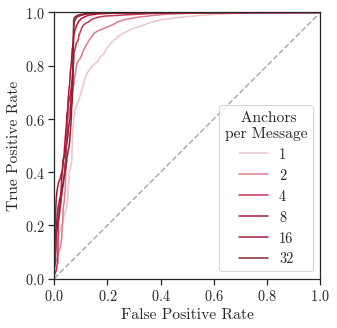

In [44]:
plot_roc_multiple(dfs_mean, hue_label="   Anchors\nper Message", size=0.4, output_pdf="roc-replay-mean.pdf")

In [30]:
df_mean = dfs_mean[4]

table_data = []

tprs = [0.999, 0.990, 0.9495, 0.899]
for tpr in tprs:
    row = df_mean.loc[df_mean[(df_mean['tpr'] >= tpr)]['fpr'].idxmin()]
    table_data.append((row.tpr, row.fpr, row.threshold))

fprs = [0.101, 0.050, 0.011, 0.001]
for fpr in fprs:
    row = df_mean.loc[df_mean[(df_mean['fpr'] <= fpr)]['tpr'].idxmax()]
    table_data.append((row.tpr, row.fpr, row.threshold))

print("TPR   | FPR   | Threshold")
print("=========================")
for row in table_data:
    print(f'{row[0]:.3f} | {row[1]:.3f} | {row[2]:.3f}')

print()
for row in table_data:
    print(f'{row[0]:.3f} & {row[1]:.3f} & {row[2]:.3f} \\\\')

TPR   | FPR   | Threshold
0.999 | 0.257 | 1.238
0.990 | 0.107 | 1.092
0.950 | 0.074 | 0.970
0.900 | 0.072 | 0.907
0.989 | 0.100 | 1.081
0.524 | 0.050 | 0.703
0.327 | 0.010 | 0.624
0.148 | 0.000 | 0.538

0.999 & 0.257 & 1.238 \\
0.990 & 0.107 & 1.092 \\
0.950 & 0.074 & 0.970 \\
0.900 & 0.072 & 0.907 \\
0.989 & 0.100 & 1.081 \\
0.524 & 0.050 & 0.703 \\
0.327 & 0.010 & 0.624 \\
0.148 & 0.000 & 0.538 \\


In [167]:
embeddings_a = embeddings[:16].reshape(-1, 512)
labels_a = labels[:16].reshape(-1)
embeddings_b = embeddings_replay
labels_b = labels_replay

embeddings_concat = np.concatenate((embeddings_a, embeddings_b))
distances = get_distances_numpy(embeddings_concat)

In [168]:
nums_anchors = [1, 2, 4, 8, 16, 32]
ordered_dists = dict()

for num_anchors in nums_anchors:
    ordered_dists[num_anchors] = get_ordered_dists(
        distances,
        embeddings_a,
        labels_a,
        embeddings_b,
        labels_b,
        num_anchors,
        10
    )

209it [00:00, 2184.10it/s]
209it [00:00, 2795.08it/s]
209it [00:00, 1979.31it/s]
209it [00:00, 1872.05it/s]
209it [00:00, 2752.23it/s]
209it [00:00, 3641.40it/s]


In [169]:
ds = [ np.mean(d) for d in ordered_dists[32] if len(d) > 0 ]
ls = [ l for l, d in zip(labels_b, ordered_dists[32]) if len(d) > 0 ]
# Map ls to unique small numbers
ls_unique = np.unique(ls)
# Randomise order
#np.random.shuffle(ls_unique)
ls_map = { l: i for i, l in enumerate(ls_unique) }
ls = [ ls_map[l] for l in ls ]
idx = list(range(len(ls)))
df = pd.DataFrame({
    'Distance': ds,
    'Label': ls,
    'Index': idx,
})

# Order the labels by their first appearance (lowest value of Index)
labels_unique = df['Label'].unique()
label_indexes = [ df[df['Label'] == label]['Index'].min() for label in labels_unique ]
labels_unique = labels_unique[np.argsort(label_indexes)]
label_indexes = np.sort(label_indexes)
label_mapping = { label: i for i, label in enumerate(labels_unique) }
df['Label'] = df['Label'].map(label_mapping)
df['Label'] = df['Label'].astype('category')

# Save df
df.to_csv(os.path.join(results_dir, 'replay_dists.csv'), index=False)

In [99]:
# Load df
df = pd.read_csv(os.path.join(results_dir, 'replay_dists.csv'))

/tmp/ipykernel_58000/768437194.py:5: UserWarning: 
The palette list has fewer values (10) than needed (31) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df, x='Index', y='Distance', hue='Label', ax=ax, palette=get_palette())


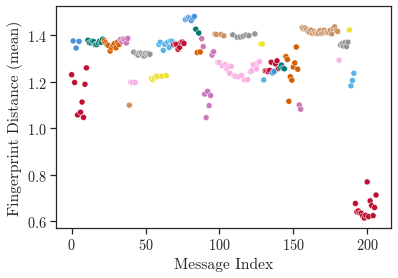

In [100]:
@plot
def plot_scatter_dists(df, size=1.0, height=1.0):
    fig, ax = plt.subplots(figsize=fig_size(size, height))

    sns.scatterplot(data=df, x='Index', y='Distance', hue='Label', ax=ax, palette=get_palette())
    # Hide legend
    plt.legend([],[], frameon=False)
    # Labels
    plt.xlabel('Message Index')
    plt.ylabel('Fingerprint Distance (mean)')

plot_scatter_dists(df, size=0.5, output_pdf='replay-dists.pdf')

## past-ai-hists.pdf

In [63]:
# Load files in data_pastai (tab-separated)
data = []
files = [ f for f in os.listdir(data_pastai) if 'txt' in f and 'orig' not in f ]
for file in tqdm(files):
    data.append(pd.read_csv(os.path.join(data_pastai, file), sep='\t', header=None))

data = pd.concat(data, ignore_index=True)

100%|██████████| 2/2 [02:22<00:00, 71.48s/it]


In [64]:
# Rename specific columns
data = data.rename(columns={
    0: 'timestamp',
    1: 'seconds',
    2: 'id',
    3: 'beam',
    9: 'samples',
})

df = data[data['beam'] == 0].copy()
df.head()

,timestamp,seconds,id,beam,4,5,6,7,8,samples
0,1599721333,2872,109,0,13.01,29.93,803,96,1626291072,"(0.000139275+0.000368208j),(-0.000203082-0.000..."
1,1599721333,11512,109,0,13.55,29.94,800,93,1626290432,"(0.000230889+0.000191844j),(-0.000268234-0.000..."
3,1599721333,20152,109,0,14.07,29.93,801,90,1626290048,"(0.00019233+0.000168464j),(-0.000226398-0.0002..."
5,1599721333,28792,109,0,14.57,29.93,802,93,1626289408,"(0.000114733+0.000228546j),(-0.000236602-0.000..."
7,1599721333,37432,109,0,15.10,29.93,801,88,1626288896,"(0.000247174+0.0001804j),(-0.000315206-0.00023..."


In [65]:
def decode_row(x):
    out = re.sub(r'\d\.\d+(e-\d+)?', '', x)
    out = re.sub(r'\(\+j\)', '1', out)
    out = re.sub(r'\(-j\)', '3', out)
    out = re.sub(r'\(--j\)', '2', out)
    out = re.sub(r'\(-\+j\)', '0', out)
    return out

df['decoded'] = df['samples'].progress_apply(decode_row)

100%|██████████| 1920147/1920147 [03:43<00:00, 8575.16it/s] 


In [66]:
df['count_0'] = df['decoded'].apply(lambda x: x.count('0'))
df['count_1'] = df['decoded'].apply(lambda x: x.count('1'))
df['count_2'] = df['decoded'].apply(lambda x: x.count('2'))
df['count_3'] = df['decoded'].apply(lambda x: x.count('3'))
df['count'] = df['count_0'] + df['count_1'] + df['count_2'] + df['count_3']

df['prop_0'] = df['count_0'] / df['count']
df['prop_1'] = df['count_1'] / df['count']
df['prop_2'] = df['count_2'] / df['count']
df['prop_3'] = df['count_3'] / df['count']
df['prop_zero'] = (df['count_0'] * 2 + df['count_1'] + df['count_2']) / (df['count'] * 2)
df['prop_one'] = (df['count_3'] * 2 + df['count_1'] + df['count_2']) / (df['count'] * 2)

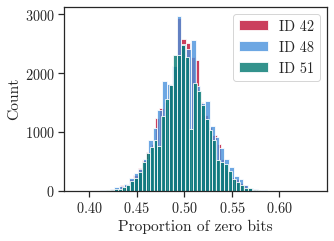

In [67]:
@plot
def plot_hists(ids, size=1.0, height=1.0):
    fig, ax = plt.subplots(1, 1, figsize=fig_size(size, height))
    for i in ids:
        plt.hist(df[df['id'] == i]['prop_zero'], bins=50, label=f'ID {i}', alpha=0.8)

    plt.xlabel('Proportion of zero bits')
    plt.ylabel('Count')
    plt.legend()

plot_hists([42, 48, 51], size=0.392, height=1.059375, output_pdf='past-ai-hists.pdf')

## past-ai-confusion.pdf

In [68]:
# Load conf
conf = np.load(os.path.join(results_dir, 'conf.py.npy'))

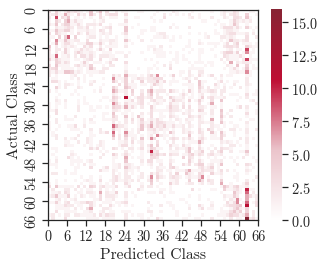

In [69]:
plot_heatmap_conf(conf, size=0.392, height=1.215, output_pdf='past-ai-confusion.pdf')

## past-ai-heatmaps.pdf

In [70]:
heatmap_files = ['base.csv', 'txrx.csv', 'txrx_single.csv']
heatmap_labels = ['Label Swap', 'Continuous SDR', 'Single Message SDR']

data = []
for file in heatmap_files:
    data.append(np.loadtxt(os.path.join(results_dir, file), delimiter=','))

print("Misclassification rates:")
for i in range(len(data)):
    misclassification_rate = 1 - (np.trace(data[i]) / np.sum(data[i]))
    print(f"    {heatmap_labels[i]:<20}: {misclassification_rate:.3f}")

Misclassification rates:
    Label Swap          : 0.287
    Continuous SDR      : 0.722
    Single Message SDR  : 0.287


/tmp/ipykernel_58000/3275756218.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, .92, 1])


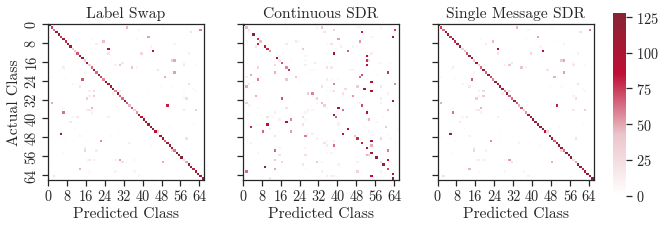

In [76]:
plot_heatmaps_confs(data, heatmap_labels, size=0.8, height=0.497, tick_spacing=8, output_pdf='past-ai-heatmaps.pdf')

## Margin Table

In [34]:
ds = TFRecordLoaderFull.from_file(os.path.join(data_dir, "2023-06-12_0.tfrecord"), all_features=False, shuffle=False)
samples = np.array([ s[0] for s in ds ])
labels = np.array([ s[1] for s in ds ])
del ds

In [35]:
models_to_test = [
    ('days-16', False, False),
    ('no-ae-16', True, False),
    ('vae-16', False, True),
    ('days-16-margin-2.0', False, False),
    ('days-16-margin-0.5', False, False),
    ('days-16-margin-0.1', False, False),
    ('days-16-margin-0.01', False, False),
    ('days-16-margin-0.05', False, False),
]
results = []

In [36]:
for model_name, no_ae, vae in tqdm(models_to_test):
    model = load_model(model_name, no_ae=no_ae, vae=vae)
    embeddings = model.model.predict(samples)
    if not no_ae:
        embeddings = embeddings[0]
    distances = get_distances_numpy(embeddings)
    distances_same, distances_diff = get_distances_same_diff(distances, labels)
    df_statistical = get_statistical_data(distances_same, distances_diff, resolution=100, verbose=False)
    auc = roc_auc(df_statistical)
    eer = find_eer(distances_same, distances_diff)

    results.append((model_name, auc, eer))

    del model

100%|██████████| 8/8 [02:48<00:00, 21.03s/it]


In [37]:
print("Model Name           | AUC   | EER  ")
print("====================================")
for model_name, auc, eer in results:
    print(f'{model_name:20} | {auc:.3f} | {eer:.3f}')

Model Name           | AUC   | EER  
days-16              | 0.674 | 0.377
no-ae-16             | 0.676 | 0.376
vae-16               | 0.499 | 0.502
days-16-margin-2.0   | 0.674 | 0.377
days-16-margin-0.5   | 0.677 | 0.374
days-16-margin-0.1   | 0.678 | 0.373
days-16-margin-0.01  | 0.665 | 0.383
days-16-margin-0.05  | 0.669 | 0.380


In [38]:
margin_data = []
margin_data.append((1.0, results[0][1], results[0][2]))
for model_name, auc, eer in results[3:]:
    if "margin" in model_name:
        margin_data.append((float(model_name.split('-')[-1]), auc, eer))
margin_df = pd.DataFrame(margin_data, columns=['Margin', 'AUC', 'EER'])
margin_df = margin_df.sort_values(by='Margin', ascending=False)
print(margin_df.to_latex(index=False))

\begin{tabular}{rrr}
\toprule
Margin & AUC & EER \\
\midrule
2.000000 & 0.673596 & 0.377031 \\
1.000000 & 0.673623 & 0.377184 \\
0.500000 & 0.676968 & 0.373603 \\
0.100000 & 0.677803 & 0.372970 \\
0.050000 & 0.668687 & 0.379689 \\
0.010000 & 0.664890 & 0.383152 \\
\bottomrule
\end{tabular}

